In [1]:
from lib import *
import numpy as np
import matplotlib.pyplot as plt

In [2]:
air = AirFlow(temp=Q_(55, u.degC), pressure=Q_(1, u.atm), humidity=Q_(20,u.perc))

In [3]:
water = WaterFlow(temp=Q_(59, u.degC), salinity=Q_(1000, u.mg/u.kg))

In [4]:
solver = MerkelSolver(C=1.1, n=0.6, air_in=air, water_in = water, water_temp_out=Q_(40, u.degC))

In [5]:
solver.estimate_temperatures(2.0)

(<Quantity(49.2243649, 'degree_Celsius')>,
 <Quantity(39.2243649, 'degree_Celsius')>,
 None)

In [6]:
air.wet_bulb_temperature()

<Quantity(31.642878, 'degree_Celsius')>

In [7]:
solver.find_operating_lg()

1.5705336821124438

In [8]:
cs = np.arange(0.5, 2.0, 0.1)
mes_2 = []
mes_05 = []

In [9]:
air = AirFlow(temp=Q_(55, u.degC), pressure=Q_(1, u.atm), humidity=Q_(40,u.perc))
water = WaterFlow(temp=Q_(59, u.degC), salinity=Q_(1000, u.mg/u.kg))

In [10]:
for c in cs:
    solver = MerkelSolver(C=c, n=0.6, air_in=air, water_in = water, water_temp_out=Q_(40, u.degC))
    _, t_cold_2, _ = solver.estimate_temperatures(2.0)
    _, t_cold_05, _ = solver.estimate_temperatures(1.0)
    mes_2.append(t_cold_2.magnitude if t_cold_2 is not None else None)
    mes_05.append(t_cold_05.magnitude if t_cold_05 is not None else None)

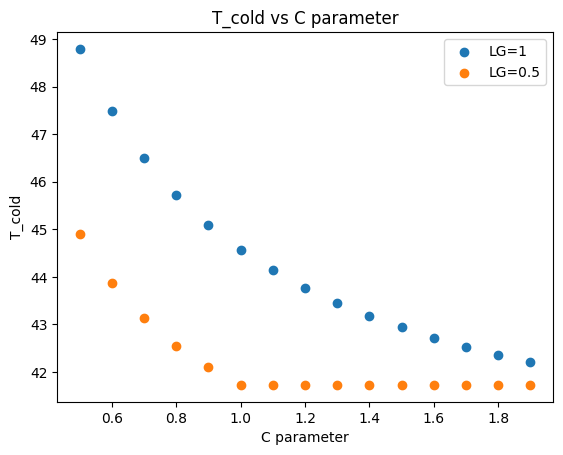

In [11]:
plt.scatter(cs, mes_2, label="LG=1")
plt.scatter(cs, mes_05, label="LG=0.5")
plt.title("T_cold vs C parameter")
plt.ylabel("T_cold")
plt.xlabel("C parameter")
plt.legend()